# Install dan Import Library
Impor semua pustaka penting yang akan digunakan untuk analisis data, visualisasi, dan pembangunan sistem rekomendasi.

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Download Dataset dari Kaggle
Mendownload dataset dari kaggle yang akan digunakan untuk sistem rekomendasi

In [ ]:
path = kagglehub.dataset_download("nikdavis/steam-store-games")
print("Path to dataset files:", path)

100%|██████████| 35.2M/35.2M [00:00<00:00, 57.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nikdavis/steam-store-games/versions/3


# Load Dataset
Membaca file CSV yang berisi data game dari platform Steam ke dalam DataFrame.

In [ ]:
df = pd.read_csv(os.path.join(path, "steam.csv"))
df.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


Dataset memiliki 18 kolom

# Visualisasi Distribusi Genre
Visualisasi distribusi 10 genre terpopuler/teratas

<ipython-input-4-e9819d9f8510>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_genres.keys()), y=list(top_genres.values()), palette='viridis')


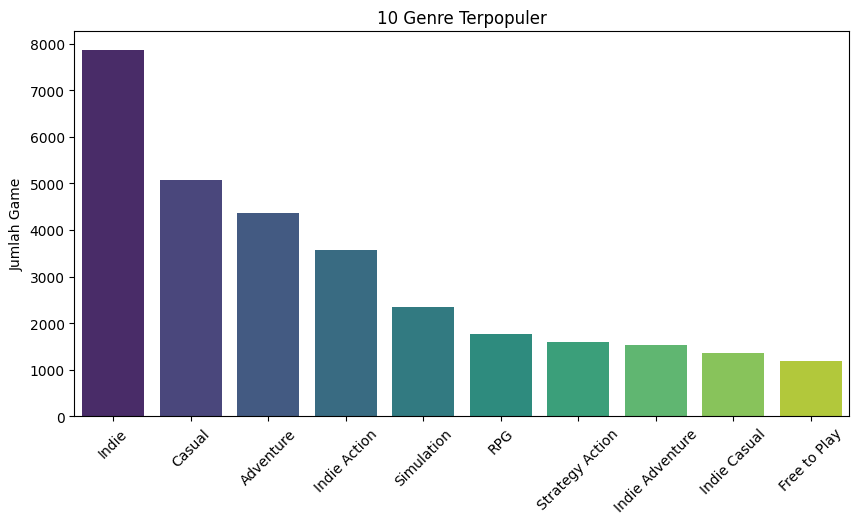

In [ ]:
# Hitung frekuensi genre
from collections import Counter
all_genres = " ".join(df['genres']).split(';')
genre_counts = Counter(all_genres)

# Visualisasikan 10 genre teratas
top_genres = dict(genre_counts.most_common(10))
plt.figure(figsize=(10,5))
sns.barplot(x=list(top_genres.keys()), y=list(top_genres.values()), palette='viridis')
plt.title("10 Genre Terpopuler")
plt.ylabel("Jumlah Game")
plt.xticks(rotation=45)
plt.show()

Dari visualisasi distribusi genre, terlihat bahwa genre dengan jumlah game terbanyak adalah Indie, diikuti oleh Casual dan Adventure. Hal ini mengindikasikan bahwa mayoritas game dalam dataset termasuk dalam genre tersebut.


# Cek informasi data
Melihat jumlah baris, kolom, tipe data, dan deteksi apakah ada missing value.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

jumlah kolom : 18, tidak ada data kosong

### Statistik Deskriptif Dataset
Menampilkan statistik deskriptif dari kolom numerik di dataset utama seperti rata-rata, standar deviasi, nilai minimum dan maksimum. Ini membantu memahami distribusi nilai dalam dataset.


In [ ]:
df.describe()

,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


### Insight dari Statistik Deskriptif Dataset

Berdasarkan hasil `df.describe()`, terdapat total **27.075 entri** pada dataset. Beberapa insight yang dapat diambil:

- **Bahasa Inggris (english):** Sebagian besar game mendukung bahasa Inggris (mean = 0.98), menunjukkan bahwa dataset didominasi oleh game internasional.
- **Umur yang disarankan (required_age):** Rata-rata batas usia adalah 3,5 tahun, namun ada game yang mewajibkan usia hingga 18 tahun.
- **Jumlah pencapaian (achievements):** Banyak game tidak memiliki pencapaian (min = 0), tapi ada game dengan hingga 9.821 pencapaian.
- **Rating Positif dan Negatif:**
  - Rata-rata rating positif adalah 1.000, namun ada game dengan rating positif lebih dari 2,6 juta.
  - Rata-rata rating negatif adalah 211, tetapi dapat mencapai lebih dari 487 ribu.
- **Durasi Bermain:**
  - Rata-rata waktu bermain adalah 149 menit, dengan median 146 menit — menunjukkan distribusi yang cukup simetris.
  - Namun, ada game dengan durasi main hingga 190.625 menit (~132 hari), yang mungkin berasal dari genre game open-world/MMO.
- **Harga Game:**
  - Harga rata-rata game adalah sekitar \$6,07, dengan mayoritas game berada pada kisaran \$1,69 (25%) hingga \$7,19 (75%).
  - Game termahal di dataset memiliki harga hingga \$421,99.

Secara keseluruhan, dataset ini menunjukkan keragaman tinggi dalam hal harga, durasi bermain, dan jumlah pencapaian. Ini penting untuk dipertimbangkan dalam proses preprocessing dan pemodelan sstem rekomendasi.



### df.columns
Memeriksa banyaknya kolom beserta namanya

In [ ]:
df.columns

Index(['appid', 'name', 'release_date', 'english', 'developer', 'publisher',
       'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags',
       'achievements', 'positive_ratings', 'negative_ratings',
       'average_playtime', 'median_playtime', 'owners', 'price'],
      dtype='object')

Dataset memiliki total 18 kolom fitur, yang mencakup informasi penting seperti:
- Identitas game (`appid`, `name`)
- Informasi pengembang dan platform (`developer`, `publisher`, `platforms`)
- Atribut konten (`genres`, `categories`, `steamspy_tags`)
- Statistik pengguna (`positive_ratings`, `negative_ratings`, `average_playtime`)
- Harga dan usia pengguna (`price`, `required_age`)

Fitur-fitur ini menjadi dasar penting dalam membangun sistem rekomendasi berbasis konten karena mencerminkan karakteristik utama setiap game.

### Menampilkan Sampel Data Game
Menampilkan 5 baris acak dari kolom `name`, `genres`, dan `categories` untuk memberikan gambaran seperti apa struktur informasi game yang tersedia dalam dataset


In [ ]:
df[['name', 'genres', 'categories']].sample(5)

,name,genres,categories
6674,Advanced Gaming Platform::Epica,Violent;Gore;Action;Indie;RPG;Simulation;Early...,Single-player;Steam Achievements;Steam Trading...
4190,Prelogate,Casual;Indie,Single-player;Steam Achievements;Steam Trading...
14010,The Chronicles of Dragon Wing - Reborn,Casual;Simulation;Strategy,Single-player;Multi-player;Online Multi-Player
19845,Gleaner Heights,Action;Adventure;Casual;Indie;RPG;Simulation,Single-player;Steam Achievements;Steam Trading...
9178,Purgatory,Action;Adventure;Indie;RPG;Strategy,Single-player;Steam Trading Cards


Dari sampel acak, terlihat bahwa:
- Format genre menggunakan pemisah titik koma (`;`), seperti `Casual;Indie`.
- Beberapa game memiliki kombinasi genre dan kategori yang sangat panjang, yang akan berdampak pada dimensi fitur setelah proses TF-IDF.
- Struktur data ini konsisten dan cocok untuk diproses lebih lanjut, misalnya digabungkan menjadi satu kolom untuk pemodelan konten.

# Data Cleaning

Hapus data yang tidak memiliki genres dan categories

In [ ]:
df = df.dropna(subset=['genres', 'categories'])

Gabungkan genres + categories

In [ ]:
df['combined'] = df['genres'] + ' ' + df['categories']

Hapus duplikat berdasarkan nama game

In [ ]:
df = df.drop_duplicates(subset='name').reset_index(drop=True)

### Insight setelah Pembersihan Data

Setelah menghapus entri yang tidak memiliki nilai pada kolom `genres` dan `categories`, serta menghapus data duplikat berdasarkan `name`, dataset menjadi lebih bersih dan siap diproses. Hal ini penting untuk menghindari noise pada sistem rekomendasi dan memastikan kualitas vektor TF-IDF yang dibentuk nantinya.

Ambil 2000 data acak untuk efisiensi

In [ ]:
df_sample = df.sample(n=2000, random_state=42).reset_index(drop=True)
df_sample['combined'] = df_sample['genres'] + ' ' + df_sample['categories']

Dataset yang semula berjumlah lebih dari 27.000 game disampling menjadi 2.000 entri. Sampling ini dilakukan untuk menghemat waktu komputasi pada tahap pemodelan, namun tetap mempertahankan keragaman konten. Pemilihan dilakukan secara acak namun konsisten (dengan `random_state`), sehingga bisa direproduksi.

Visualisasi panjang teks terhadap jumlah game

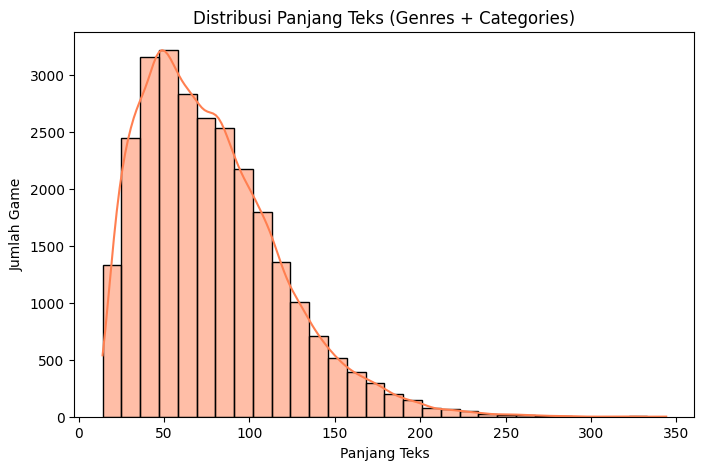

In [ ]:
df['combined_length'] = df['combined'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(df['combined_length'], bins=30, kde=True, color='coral')
plt.title("Distribusi Panjang Teks (Genres + Categories)")
plt.xlabel("Panjang Teks")
plt.ylabel("Jumlah Game")
plt.show()

Dari histogram, terlihat bahwa sebagian besar game memiliki kombinasi teks genre dan kategori dengan panjang antara **30 hingga 100 karakter**. Distribusi ini cenderung **right-skewed**, artinya ada sebagian kecil game dengan deskripsi yang sangat panjang (di atas 200 karakter), yang berpotensi menjadi outlier.

# Modelling
Mengubah teks pada kolom `combined` menjadi vektor numerik menggunakan TF-IDF Vectorizer, lalu menghitung kemiripan antar game menggunakan cosine similarity. Ini menjadi dasar sistem rekomendasi berbasis konten.

Membuat dua pemetaan nama game ke indeks:
- `indices_full` untuk dataset lengkap,
- `indices_sample` untuk dataset sampel (2000 game),
Agar fungsi rekomendasi dapat mengambil indeks game berdasarkan naa.


In [ ]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_sample['combined'])
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# Mapping nama game -> index di dataset lengkap
indices_full = pd.Series(df.index, index=df['name']).drop_duplicates()

# Mapping nama game -> index di dataset sample
indices_sample = pd.Series(df_sample.index, index=df_sample['name']).drop_duplicates()

# Fungsi rekomendasi
def recommend(game_title, n=5):
    if game_title not in indices_full:
        return f"Game '{game_title}' tidak ditemukan di dataset lengkap."

    if game_title not in indices_sample:
        return f"Game '{game_title}' tidak tersedia di sample data."

    idx = indices_sample[game_title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n+1]
    game_indices = [i[0] for i in sim_scores]
    return df_sample['name'].iloc[game_indices].tolist()

Kode tersebut merupakan bagian dari sistem rekomendasi berbasis konten yang menggunakan metode TF-IDF dan cosine similarity untuk merekomendasikan game yang mirip berdasarkan deskripsi gabungan (fitur teks). Proses dimulai dengan mengubah teks menjadi representasi numerik menggunakan TF-IDF, lalu menghitung tingkat kemiripan antar game dengan cosine similarity. Sistem ini membuat dua mapping, yaitu dari nama game ke indeks dalam dataset lengkap dan dalam dataset sampel. Fungsi recommend bertugas untuk memberikan rekomendasi game serupa berdasarkan judul game yang diberikan, dengan terlebih dahulu memeriksa apakah judul tersebut ada di kedua dataset. Jika ditemukan, maka sistem akan mencari beberapa game terdekat berdasarkan nilai kesamaan tertinggi, dan mengembalikannya sebagai daftar rekomendasi. Pendekatan ini cocok digunakan untuk demo atau prototipe sistem rekomendasi karena efisien dan mudah dikembangkan.

# Contoh Rekomendasi

### Contoh Nama Game Secara Acak
Menampilkan 10 nama game secara acak dari dataset sample untuk melihat game apa saja yang tersedia setelah proses sampling


In [ ]:
print(df_sample['name'].sample(10).tolist())

['Space mining clicker', 'Drunken Fight Simulator', 'Virtual Desktop', 'Miniballist', 'AntharioN', 'The Cubicle.', 'Monster RPG 3', 'Deus Ex Machina, Game of the Year, 30th Anniversary Collector’s Edition', '武儒绘卷 - 九五至尊', 'Containment']


Hasil rekomendasi menunjukkan kemiripan genre/kategori

### Fungsi Rekomendasi Game Mirip
Fungsi `recommend()` digunakan untuk mencari dan mengembalikan daftar Top-N game yang paling mirip dengan input judul game. Kemiripan didasarkan pada cosine similarity dari konten genre dan kategori


In [ ]:
print(recommend("Flatshot", 5))

['Blood Waves', 'Devil Engine', 'Hyperspace Pinball', 'Scrap Attack VR', 'Energy Hook']


fungsi berhasil menghasilkan Top-N game mirip

### Evaluasi: Perhitungan Precision@K

Untuk mengevaluasi sistem rekomendasi Content-Based Filtering, kita akan menggunakan simulasi sederhana dengan Precision@K. Kita anggap bahwa game yang memiliki genre/kategori sama dengan input dianggap relevan (ground truth disimulasikan).


In [ ]:
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)
    hit = sum([1 for item in recommended_k if item in relevant_set])
    return hit / k

# Simulasi evaluasi untuk 1 game
input_game = "Flatshot"
recommended_games = recommend(input_game, 5)

# Simulasikan relevan game (anggap genre 'Action' dan 'Indie' adalah relevan)
input_genres = df[df['name'] == input_game]['genres'].values[0].split(';')
relevant_games = df[df['genres'].str.contains('|'.join(input_genres))]['name'].tolist()
score = precision_at_k(recommended_games, relevant_games, k=5)

print(f"Precision@5 untuk '{input_game}': {score:.2f}")

Precision@5 untuk 'Flatshot': 1.00
